In [17]:
import pandas as pd

from libs.preprocessing import MetaboPreprocer
from libs.multivariate_analysis import MultiVariateAnalysis

import warnings
warnings.filterwarnings('ignore')

In [18]:
cd C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline

C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline


In [19]:
# Prepared the (prefiltered or scaled) dataset

preprocessor = MetaboPreprocer(
    step_blank_substrateion=True,
    step_filter_rsd=False,
#    filter_ratio=0.3,
    qc_label='QC',
    scaling='log_pareto',
    file_save=False,
#    criteria_ND_proportion=0.5
)


df_scaled, df_ori = preprocessor.preprocessing(
    'Compounds_merged.xlsx',
    sheet_name='serum_pos_tp',
    label_list= ['Control', 'VNAM']
)

=========== Preprocessing ==========
Original dataset shape (n_samples, n_features + 2) = (21, 1928)
A total of 0 missing values were detected
========== Substrate the blank intensity from raw(original) intensity ==========
Removal of featuers with more than 50.0% proportion of negative values in all groups
Before the substration process, dataset shape (n_samples, n_features + 2) = (21, 1928).
After the substration process, dataset shape (n_samples, n_features + 2) = (18, 1675).
========== Label Selectioin ==========
['Control', 'VNAM'] features are selected and scaled
Processed dataset shape (n_samples, n_features + 2) = (15, 1675)



In [20]:
# or directly read the dataset
# df_scaled = pd.read_csv('./data/dataset_filtered_scaled.csv')

In [21]:
multi_analysis= MultiVariateAnalysis(n_components=5)

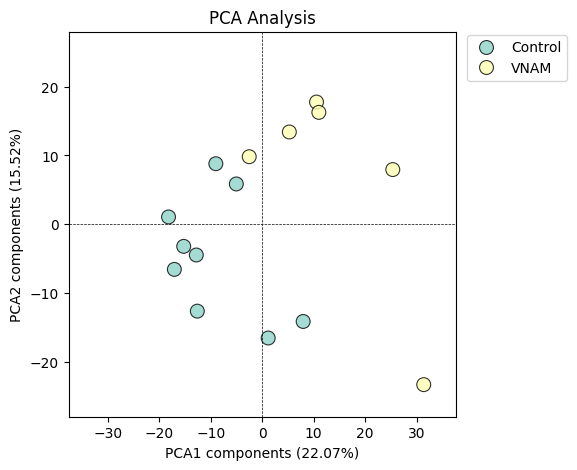

In [22]:
_ = multi_analysis.pca_analysis(df_scaled)

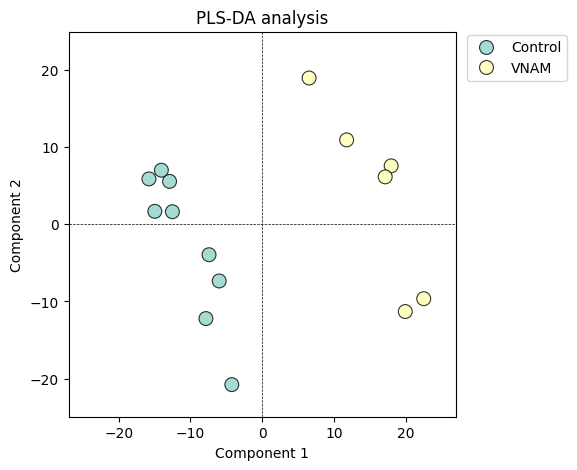

In [23]:
_ = multi_analysis.plsda_analysis(df_scaled)

=========== Preprocessing ==========
Original dataset shape (n_samples, n_features + 2) = (21, 1928)
A total of 0 missing values were detected
========== Substrate the blank intensity from raw(original) intensity ==========
Removal of featuers with more than 50.0% proportion of negative values in all groups
Before the substration process, dataset shape (n_samples, n_features + 2) = (21, 1928).
After the substration process, dataset shape (n_samples, n_features + 2) = (18, 1675).
========== Label Selectioin ==========
['Control', 'VNAM', 'QC'] features are selected and scaled
Processed dataset shape (n_samples, n_features + 2) = (18, 1675)



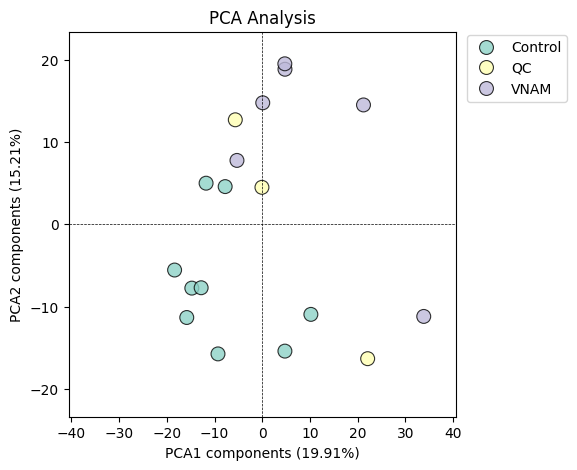

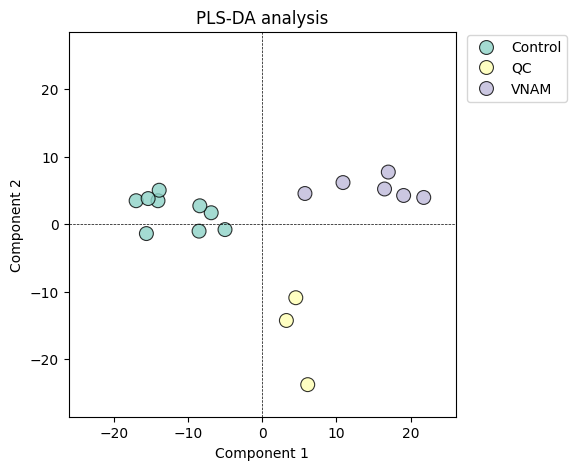

In [24]:
# preprocessor enables to select the label(group class)
# eg, [Control, Severe, Moderate, Mild] to [Control, Severe]

df_scaled, df_ori = preprocessor.preprocessing(
    'Compounds_merged.xlsx',
    sheet_name='serum_pos_tp',
    label_list= ['Control', 'VNAM', 'QC']
)

_ = multi_analysis.pca_analysis(df_scaled)
_ = multi_analysis.plsda_analysis(df_scaled)